In [2]:
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib as mpl        # Only to check the version we are working with
import matplotlib.pyplot as plt # We will be mainly using this file, instead of the whole library. That's why we give it a separated handle

        W0        W1        W2
0     -7.0  1.000000  2.000000
1     -7.0  1.068667  1.184287
2     -7.0  1.420690 -0.427688
3     -7.0  0.395880  0.597241
4     -7.0 -1.114853 -2.163052
...    ...       ...       ...
9996  -7.0 -4.253631  4.475603
9997  -7.0 -4.253665  4.475639
9998  -7.0 -4.253700  4.475676
9999  -7.0 -4.253735  4.475712
10000 -7.0 -4.253769  4.475749

[10001 rows x 3 columns]


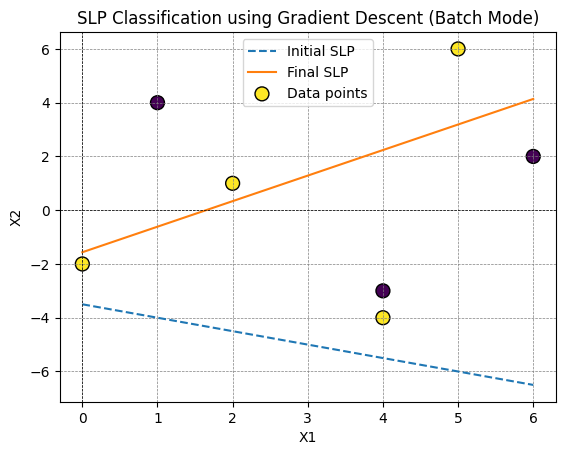

In [ ]:
# GRADIENT DESCENT SLP ALGORITHM (BATCH MODE)
alpha = 1 # Learning rate
max_epochs = 10000 # Maxium number of iterations (epochs)
# Data
X = np.array([[0, -2], [1, 4], [2, 1], [4, -4], [4, -3], [5, 6], [6, 2]]) # Data (original)
Xt = np.c_[-1*np.ones(X.shape[0]), X] # Data with one column full of -1s (to apply the thresold, the first weight)
Xt_std = Xt.std(axis=0)
Xt_std[Xt_std == 0] = 1  # Replace 0 with 1 to avoid division by zero
Xt = (Xt - Xt.mean(axis=0)) / Xt_std
# Labels
y = np.array([1, -1, 1, 1, -1, 1, -1]) # Labels (original)
# Weights
W0 = [-7, 1, 2] # Initial weights
W = np.array(W0, dtype=float).copy() # Vector that we will update at each epoch
Whist = np.zeros((max_epochs,len(W0))) # Vector to save all the weights in our run

# Gradient descent algorithm
for i in range(max_epochs):
    dE = np.zeros(len(W0)) # Restart the vector where we store dE/dW (each epoch is a different value)
    for j in range(len(Xt)):
        g = np.tanh(np.clip(np.dot(Xt[j],W),-100,100))
        for k in range(len(dE)):
            dE[k] += (y[j]-g) * Xt[j][k] * (1-g**2) # Notice how we are storing the values without ereasing anything until we change the epoch and update the weights (batch update)
    for l in range(len(W)):
        W[l] = W[l] + alpha*dE[l] # Update the weights (each one independently) before moving to the next epoch
    Whist[i] = W # Store the new values of the weights    
Whist = np.vstack([W0, Whist]) # Add a new row at the top of Whist with the initial weights

df = pd.DataFrame(Whist, columns=['W0', 'W1', 'W2'])
print(df)   

# Final SLP
SLPf = -(W[1]/W[2])*x + W[0]/W[2]
# Plot
plt.plot(x, SLPi, label='Initial SLP', linestyle='--')
plt.plot(x, SLPf, label='Final SLP', linestyle='-')
plt.scatter(X[:,0], X[:,1], c=y, marker='o', s=100, edgecolors='k', label='Data points')
plt.title('SLP Classification using Gradient Descent (Batch Mode)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.show()